# Limiarização de imagens

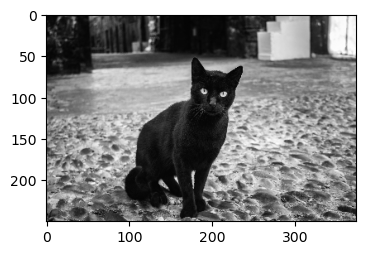

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img = plt.imread("../../dados/cat.tiff")
plt.imshow(img, "gray")

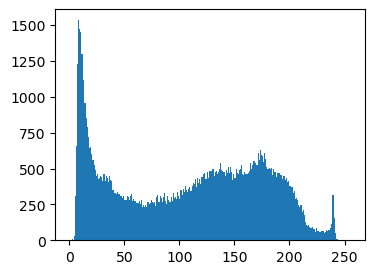

In [2]:
_ = plt.hist(img.ravel(), range(257))

## 1. Limiarização simples

Vamos tentar segmentar o gato da imagem acima. Primeiro, utilizaremos um método simples de médias sucessivas.

In [3]:
def simple_threshold(img):
    """Estima limiar através do cálculo das médias de intensidade dos pixels
       background e foreground"""
    
    num_rows, num_cols = img.shape
    threshold = np.mean(img)
    has_finished = False
    while not has_finished:
        print(threshold)
        
        # Gera imagem binária conforme o valor é mario ou menor que o limiar
        img_bin = img > threshold
        # Calcula as médias de intensidade dos pixels background e foreground
        # ~img_bin é a negação de img_bin, ou seja, os pixels que são background
        mean_back = np.mean(img[img_bin])
        mean_fore = np.mean(img[~img_bin])     
        
        prev_threshold = threshold
        threshold = (mean_back+mean_fore)/2
        if np.abs(threshold-prev_threshold)<1e-6:
            has_finished = True
                        
    return threshold

107.110016
103.03784741892899
101.23384919590512
100.36097551526422
99.90981434502736
99.53850551142071
Threshold escolhido: 99.53850551142071


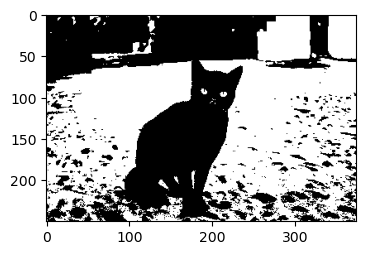

In [4]:
thresh = simple_threshold(img)
print(f"Threshold escolhido: {thresh}")
binary_image = img>=thresh
plt.imshow(binary_image, "gray")

## 2. Limiarização de Otsu

A limiarização de Otsu consiste em encontrar o limiar tal que o valor de

\begin{equation}
\sigma_I^2=P_B(m_B-m_G)^2+P_F(m_F-m_G)^2
\end{equation}

seja máximo.

In [ ]:
def threshold_otsu_naive(img):
    """Calcula o limiar de Otsu de forma ineficiente, mas simples de ser entendida"""
    
    num_pixels = img.shape[0]*img.shape[1]   # Número de pixels na imagem
    m_g = np.sum(img)/num_pixels             # Intensidade média
    
    max_sigma = -1
    # Para cada limiar possível
    for threshold in range(0, 256):

        img_bin = img > threshold

        num_fore = img_bin.sum()  # Número de pixels foreground
        num_back = num_pixels - num_fore  # Número de pixels background

        # Trata o caso especial em que todos os pixels são foreground ou background
        if num_back==0 or num_fore==0:
            continue
        
        m_fore = np.mean(img[img_bin])  # Média de intensidade dos pixels foreground
        m_back = np.mean(img[~img_bin])  # Média de intensidade dos pixels background

        p_back = num_back/num_pixels  # Fração de pixels background
        p_fore = num_fore/num_pixels  # Fração de pixels foreground

        sigma = p_back*(m_back-m_g)**2 + p_fore*(m_fore-m_g)**2
        
        if sigma > max_sigma:
            max_sigma = sigma
            best_threshold = threshold
    
    return best_threshold

thresh = threshold_otsu_naive(img)
print(f"Threshold escolhido: {thresh}")

Threshold escolhido: 99


O valor ótimo de sigma pode ser calculado de forma muito mais eficiente utilizando o histograma da imagem:

In [13]:
def threshold_otsu(img):
    """Calcula o limiar de Otsu utilizando o histograma da imagem"""
    
    bins = range(0, 257)
    hist, _ = np.histogram(img, bins)
    
    num_pixels = img.shape[0]*img.shape[1] 
    sum_img = np.sum(img)
    m_g = sum_img/num_pixels
    max_sigma = -1

    sum_back = 0
    num_back = 0
    for threshold in range(0, 256):
        num_back = num_back + hist[threshold]  # Número de pixels com valor menor que threshold
        sum_back = sum_back + threshold*hist[threshold]  # Soma dos valores de pixel background

        num_fore = num_pixels - num_back
        sum_fore = sum_img - sum_back
        
        if num_back == 0 or num_fore == 0:
            continue
        
        p_back = num_back/num_pixels
        p_fore = num_fore/num_pixels
        m_back = sum_back/num_back   
        m_fore = sum_fore/num_fore    
        
        sigma = p_back*(m_back-m_g)**2 + p_fore*(m_fore-m_g)**2
        
        if sigma > max_sigma:
            max_sigma = sigma
            best_threshold = threshold

    return best_threshold

thresh = threshold_otsu(img)
print(f"Threshold escolhido: {thresh}")

Threshold escolhido: 99
